In [152]:
#########################################################
##  Implementation of HW 5 Question 1, CS160 Spring22  ##
#########################################################

# Input: array (of ints) of stone damage values, and dragon health value (int)
# Returns: integer, the minimum number of stones needed to kill the dragon
# Implemented using top-down dynamic programming
import sys
import time
import numpy as np
from numpy import random
import matplotlib.pyplot as plt
import math

def magic_stones_topdown_helper(memo, stones, health):
    if health < 0: # Case 1
        return sys.maxsize
    if health == 0: # Case 2
        return 0
    elif health in memo:
        return memo[health]
    else: # Recursion
        memo[health] = 1 + magic_stones_topdown_helper(memo, stones, health-stones[0]);
        for i in range(1, len(stones)):
            # print(memo[health], 1 + magic_stones_topdown(stones, health-stones[i]))
            if (1 + magic_stones_topdown_helper(memo, stones, health-stones[i])) < memo[health]:
                memo[health] = 1 + magic_stones_topdown_helper(memo, stones, health-stones[i])
    return memo[health]

def magic_stones_topdown(stones, health):
    # TODO: Implement
    start_time = time.time()
    memo = {}
    memo_result = magic_stones_topdown_helper(memo, stones, health)
    return memo_result, (time.time() - start_time)
# "%s seconds" % (time.time() - start_time)

# Input: array (of ints) of stone damage values, and dragon health value (int)
# Returns: integer, the minimum number of stones needed to kill the dragon
# Implemented using bottom-up dynamic programming
# def magic_stones_bottomup(stones, health):
#     # TODO: Implement
#     start_time = time.time()
#     if health < 0: # Case 1
#         return sys.maxsize
#     if health == 0: # Case 2
#         return 0
#     table = [0] * (health + stones[-1])
#     table[0] = 0
#     for i in range(-stones[-1]+1, 0):
#         table[i] = sys.maxsize
#     for j in range(1, health + 1):
#         table[j] = 1 + table[j-stones[0]];
#         for k in range(1, len(stones)):
#             if (1 + table[j-stones[k]] < table[j]):
#                 table[j] = 1 + table[j-stones[k]]
#     return table[health], (time.time() - start_time)

def magic_stones_bottomup(stones, health):
    start_time = time.time()
    if health < 0: # Case 1
        return sys.maxsize
    if health == 0: # Case 2
        return 0
    table = [0] * (health + stones[-1])
    table[0] = 0
    for i in range(-stones[-1]+1, 0):
        table[i] = sys.maxsize
    for j in range(1, health + 1):
        table[j] = 1 + table[j-stones[0]];
        for k in range(1, len(stones)):
            if (1 + table[j-stones[k]] < table[j]):
                table[j] = 1 + table[j-stones[k]]
    return table[health], time.time() - start_time
    # TODO: Implement
    ...

#########################################################
##  Implementation of HW 2 Question 2, CS160 Spring22  ##
#########################################################

# Input: array of integers
# Returns: integer, the number of flips in the array
def count_flips(arr):
    start_time = time.time()
    flipped = []
    # Define the count of the loops as the length of the arrayfrom calc import addNumbers, multiplyNumbers
    count_loops = len(arr)
    # First, iterate the number of elements for each loop
    for i in range(2, count_loops+1):
        # At each loop, compare every two elements and do flips if necessary
        for j in reversed(range(0, i-1)):
            pre = arr[j]
            post = arr[j+1]
            if (pre > post):
                arr[j] = post
                arr[j+1] = pre
                # Append each flip to the array named "flipped"
                flipped.append([pre, post])
    return len(flipped), (time.time() - start_time)
    ...

In [93]:
stones = [1, 4, 6, 11, 25]
health = 228
magic_stones_bottomup(stones, health)

(11, 0.0004839897155761719)

In [46]:
stones = random.randint(100, size=(100)); health = 83
magic_stones_bottomup(stones, health)

(1, 0.006551980972290039)

In [161]:
# from implement_hw import magic_stones_topdown, magic_stones_bottomup, count_flips
# stones = random.randint(100, size=(100)); health = 100
# magic_stones_topdown(stones, health)
len_arr = 15; base = 1; # health = 120
n = []; T_n = []; n_log = []; T_log = []
for i in range(1, len_arr):
    n.append(base); n_log.append(math.log2(base))
    arr = random.randint(100, size=(base));
    num_stones, time_cons = count_flips(arr);
    T_n.append(time_cons); T_log.append(math.log2(time_cons*100000))
    base = base * 2;
# stones = random.randint(50, size=(65536*100)); health = 120
# magic_stones_bottomup(stones, health)

In [164]:
# 262144*2
arr = random.randint(100, size=(8192*2));
num_stones, time_cons = count_flips(arr);
T_n.append(time_cons); T_log.append(math.log2(time_cons*100000))
n.append(8192*2); n_log.append(math.log2(8192*2))

In [168]:
for i in range(0, len(T_n)):
    print(T_log[i])

-0.930927906925891
0.492283523798653
0.3645279766002803
1.8093128192731762
3.560925189403784
6.406085733498662
7.685788002459317
9.567785335257263
11.282921941516319
12.388558195146096
13.92463741818219
16.993433873828543
18.501829452334025
21.58776131722672
24.23361992453491


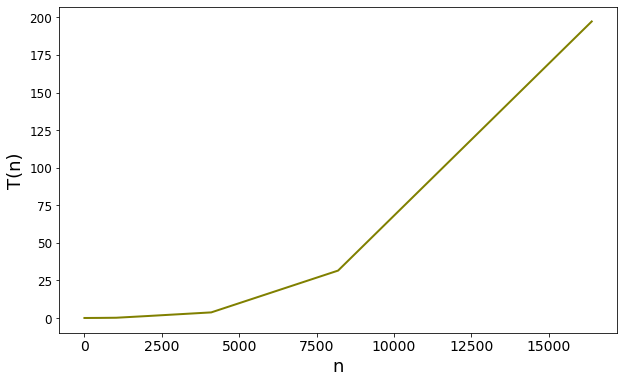

In [166]:
import matplotlib.pyplot as plt
import math
plt.figure(figsize=(10, 6))
y = T_n
x = n
plt.plot(x, y, linewidth=2, color='olive')
plt.xticks(fontsize=14); plt.yticks(fontsize=12)
plt.xlabel('n', fontsize=18)
plt.ylabel('T(n)', fontsize=18)

# plt.savefig('pupil_signal.jpg', dpi=300, quality=80, optimize=True, progressive=True)  

plt.show()

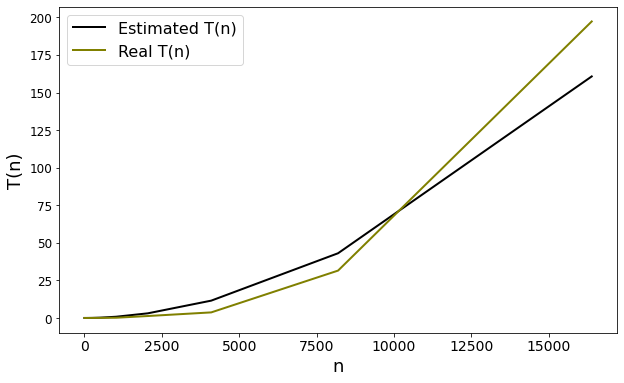

In [178]:
# [1.04060765 1.89367574]
plt.figure(figsize=(10, 6))
x = n; y_new = []
for i in range(0, len(x)):
    y_new.append((2**(-2.66211987)) * (n[i]**((1.9))) / 100000)
y = y_new
plt.plot(n, y_new, linewidth=2, color='black', label='Estimated T(n)')
plt.plot(n, T_n, linewidth=2, color='olive', label='Real T(n)')
plt.xticks(fontsize=14); plt.yticks(fontsize=12)
plt.xlabel('n', fontsize=18)
plt.ylabel('T(n)', fontsize=18)
plt.legend(loc="upper left")

# plt.savefig('pupil_signal.jpg', dpi=300, quality=80, optimize=True, progressive=True)  

plt.show()

[ 1.78857467 -2.66211987]
 
1.789 x - 2.662


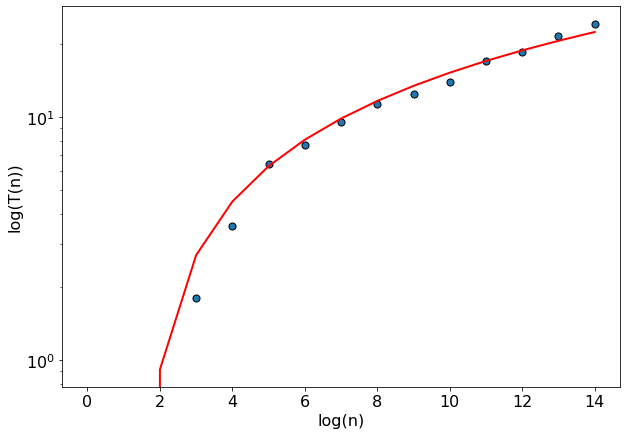

In [169]:
from scipy.optimize import curve_fit
import matplotlib
y = T_log
x = n_log
# fig, ax = plt.subplots(figsize = (9, 6))
# plt.yscale('symlog')
# ax.scatter(x, y, edgecolors="k")

# Set logarithmic scale on the both variables
# ax.set_xscale("log")
# ax.set_yscale("log");

# fig = plt.figure()
# ax=plt.gca() 
# ax.scatter(x,y,c="blue",alpha=0.95,edgecolors='none', label='data')
# ax.set_yscale('log')
# ax.set_xscale('log')

# m, c = np.polyfit(logA, logB, 1, w=np.sqrt(y)) # fit log(y) = m*log(x) + c
# y_fit = np.exp(m*logA + c) # calculate the fitted values of y 

# Coefficients for polynomial function (degree 1) 
coefs = np.polyfit(x, y, 1)
print(coefs)
fit_coefs = np.poly1d(coefs)
print(fit_coefs)

# x_lin_reg = range(0, 51)
# y_lin_reg = fit_coefs(x_lin_reg)
# plt.scatter(x, y)
# plt.plot(x_lin_reg, y_lin_reg, c = 'r')

plt.figure(figsize=(10, 7))
plt.scatter(x, y, s = 50, edgecolors = 'black') 
plt.plot(x, fit_coefs(x), color='red', linestyle='-', linewidth=2)
plt.xlabel('log(n)') 
plt.ylabel('log(T(n))')
plt.rcParams.update({'font.size': 16})
plt.yscale('log')

In [28]:
run -i 'tester.py'

In [ ]:
x = random.randint(100, size=(100))
print(x)
arr = [3, 4, 9, 5, 2, 10]; 
count_flips(x)